In [1]:
import os
os.chdir('..')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sqlcompletions import bandits
from sqlcompletions.sqlparser import schema
from sqlcompletions.evaluator import run_tuning

db = schema()

# Tune pUCB

## Tune alpha

Best parameter for: pUCB, K=5, Clause=Select, Dataset=TH50 ,  alpha = 0.1
Best parameter for: pUCB, K=3, Clause=From, Dataset=TH50 ,  alpha = 0.1
Best parameter for: pUCB, K=3, Clause=Where, Dataset=TH50 ,  alpha = 0.1


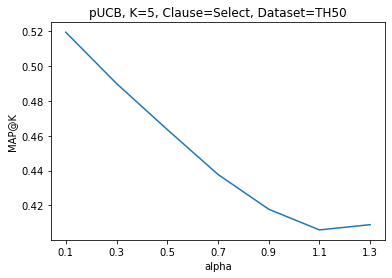

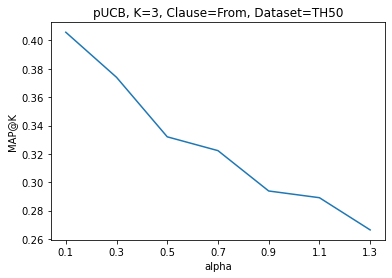

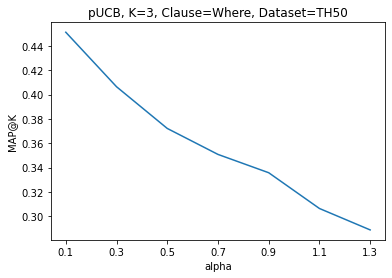

In [3]:
alphas = np.arange(0.1,1.4,0.2)
clauses_to_test = [0,1,2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

for clause in clauses_to_test:
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            n = db.n_tables if clause == 1 else db.n_columns
            log = "log_th" + str(th) + ".json"
            tests = []
            for alpha in alphas:
                tests.append(
                    dict(
                        clause=clause,
                        bandit=bandits.pUCB(alpha, 0.5, n, feedback=0),
                        top_k=k,
                        db=db,
                        log_file=log,
                        max_iterations=0.1,
                        parameter_name = 'alpha',
                        parameter_value = alpha,
                        comment= "pUCB"
                    )
                )
            run_tuning(tests)


## Tune personalization parameter

Best parameter for: pUCB, K=5, Clause=Select, Dataset=TH50 ,  p = 0.1
Best parameter for: pUCB, K=3, Clause=From, Dataset=TH50 ,  p = 0.7
Best parameter for: pUCB, K=3, Clause=Where, Dataset=TH50 ,  p = 0.2


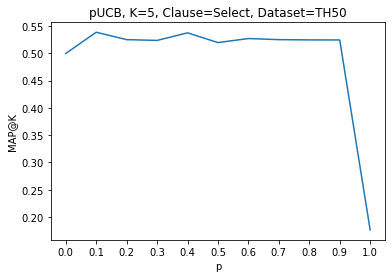

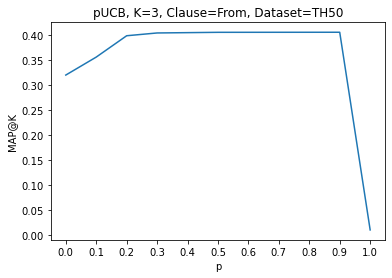

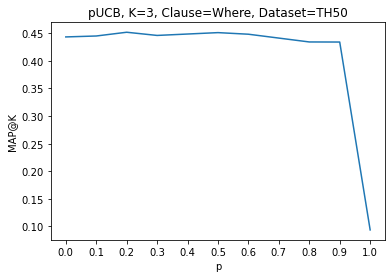

In [9]:
ps = np.arange(0, 1.1,0.1)
clauses_to_test = [0,1,2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

for clause in clauses_to_test:
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            n = db.n_tables if clause == 1 else db.n_columns
            log = "log_th" + str(th) + ".json"
            tests = []
            for p in ps:
                tests.append(
                    dict(
                        clause=clause,
                        bandit=bandits.pUCB(0.1, p, n, feedback=0),
                        top_k=k,
                        db=db,
                        log_file=log,
                        max_iterations=0.1,
                        parameter_name = 'p',
                        parameter_value = p,
                        comment= "pUCB"
                    )
                )
            run_tuning(tests)


# Tune UCB

Best parameter for: UCB1, K=5, Clause=Select, Dataset=TH50 ,  alpha = 0.1
Best parameter for: UCB1, K=3, Clause=From, Dataset=TH50 ,  alpha = 0.1
Best parameter for: UCB1, K=3, Clause=Where, Dataset=TH50 ,  alpha = 0.1
CPU times: user 265 ms, sys: 190 ms, total: 456 ms
Wall time: 4.82 s


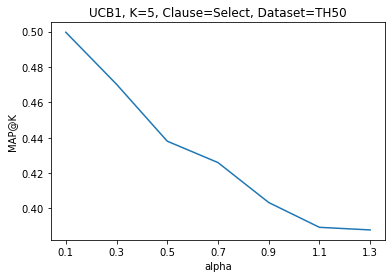

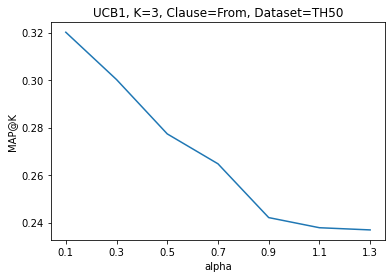

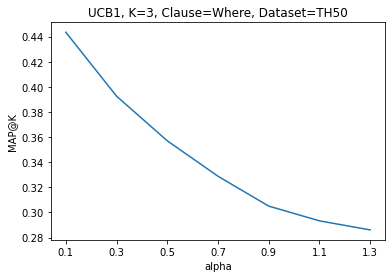

In [5]:
%%time
alphas = np.arange(0.1,1.4,0.2)
clauses_to_test = [0,1,2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

for clause in clauses_to_test:
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            n = db.n_tables if clause == 1 else db.n_columns
            log = "log_th" + str(th) + ".json"
            tests = []
            for alpha in alphas:
                tests.append(
                    dict(
                        clause=clause,
                        bandit=bandits.Ucb(alpha,n, feedback=0),
                        top_k=k,
                        db=db,
                        log_file=log,
                        max_iterations=0.1,
                        parameter_name = 'alpha',
                        parameter_value = alpha,
                        comment= "UCB1"
                    )
                )
            run_tuning(tests)


# Tune LinUCB

Best parameter for: LinUCB, K=5, Clause=Select, Dataset=TH50 ,  alpha = 0.5
Best parameter for: LinUCB, K=3, Clause=From, Dataset=TH50 ,  alpha = 0.3
Best parameter for: LinUCB, K=3, Clause=Where, Dataset=TH50 ,  alpha = 0.3
CPU times: user 595 ms, sys: 521 ms, total: 1.12 s
Wall time: 1min 4s


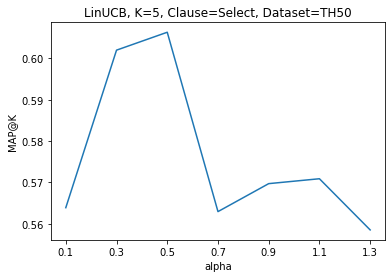

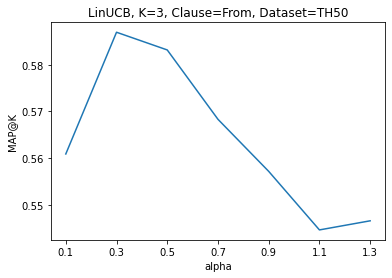

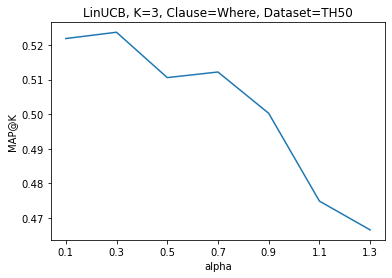

In [6]:
%%time
alphas = np.arange(0.1,1.4,0.2)
clauses_to_test = [0,1,2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

for clause in clauses_to_test:
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            n = db.n_tables if clause == 1 else db.n_columns
            log = f"/linucb/log_{clause}_pca14_1_th{th}.json"
            tests = []
            for alpha in alphas:
                tests.append(
                    dict(
                        clause=clause,
                        bandit=bandits.LinUCB(alpha,n, 15, feedback=0),
                        top_k=k,
                        db=db,
                        log_file=log,
                        max_iterations=0.1,
                        parameter_name = 'alpha',
                        parameter_value = alpha,
                        comment= "LinUCB"
                    )
                )
            run_tuning(tests)


# Tune Exp3

Best parameter for: Exp3, K=5, Clause=Select, Dataset=TH50 ,  gamma = 0.2
Best parameter for: Exp3, K=3, Clause=From, Dataset=TH50 ,  gamma = 0.1
Best parameter for: Exp3, K=3, Clause=Where, Dataset=TH50 ,  gamma = 0.1
CPU times: user 205 ms, sys: 146 ms, total: 350 ms
Wall time: 37.6 s


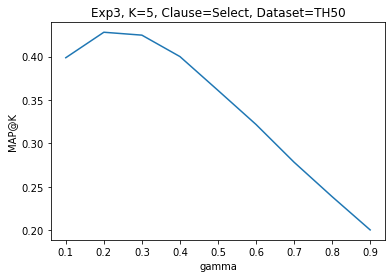

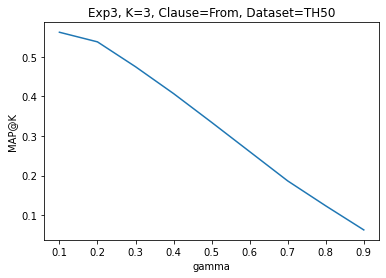

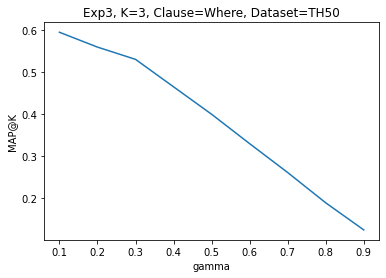

In [7]:
%%time
gammas = np.arange(0.1,1,0.1)
clauses_to_test = [0,1,2]
k_to_test = [[5],[3],[3]]
thresholds_to_test = [50]

for clause in clauses_to_test:
    for k in k_to_test[clause]:
        for th in thresholds_to_test:
            n = db.n_tables if clause == 1 else db.n_columns
            log = "log_th" + str(th) + ".json"
            tests = []
            for gamma in gammas:
                tests.append(
                    dict(
                        clause=clause,
                        bandit=bandits.Exp3(n,gamma, feedback=0),
                        top_k=k,
                        db=db,
                        log_file=log,
                        max_iterations=None,
                        parameter_name = 'gamma',
                        parameter_value = gamma,
                        comment= "Exp3"
                    )
                )
            run_tuning(tests)
